In [ ]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import torcwa
from tqdm.notebook import tqdm
from pvlib import spectrum
from refractiveindex import RefractiveIndexMaterial
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import *

%load_ext line_profiler

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
inc_ang = 30.*(np.pi/180)    # radian
azi_ang = 30.*(np.pi/180)    # radian

# geometry
h = 1000 #nm
grating_period = 1000 # nm
L = [grating_period, 1.]  # nm
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 100
torcwa.rcwa_geo.ny = 1
torcwa.rcwa_geo.grid()
z = torch.linspace(-h,1.5*h,501,device=device)

x_axis = torcwa.rcwa_geo.x.cpu()
y_axis = torcwa.rcwa_geo.y.cpu()
z_axis = z.cpu()

x = torch.clone(torcwa.rcwa_geo.x)
y  = torch.clone(torcwa.rcwa_geo.y)
z = torch.clone(z)

n_wavelength = 30
print(wavelengths[n_wavelength])

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
tensor(542)


In [14]:
#Sanity check of staircase approximation
num_layers = 250
params = torch.tensor([[20,0],[20,np.pi],[20,0]], dtype=geo_dtype, device=device)
eps = get_staircase_sine_eps(x, params, grating_period, num_layers, si_eps[0], eps_low=1.)

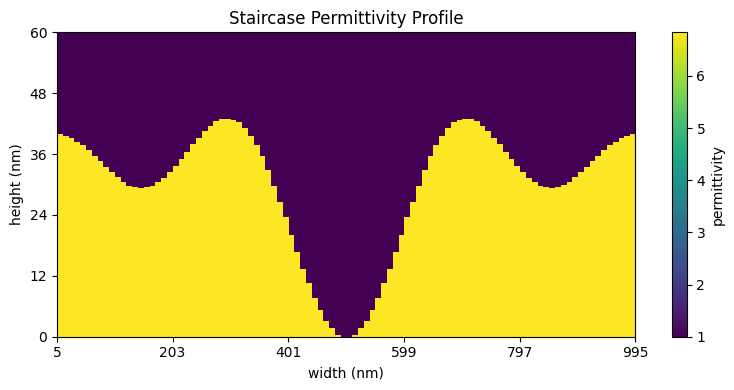

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
x_min_nm = x_axis.min().item()
x_max_nm = x_axis.max().item()
y_min_nm = 0.0
y_max_nm = float(sum(params[:,0]))

im = ax.imshow(
    eps.cpu().T,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    interpolation='none',
    extent=[x_min_nm, x_max_nm, y_min_nm, y_max_nm],
)

ax.set_xticks(np.linspace(x_min_nm, x_max_nm, 6))
ax.set_yticks(np.linspace(y_min_nm, y_max_nm, 6))
ax.set_xlabel('width (nm)')
ax.set_ylabel('height (nm)')
ax.set_title('Staircase Permittivity Profile')
fig.colorbar(im, ax=ax, label='permittivity')
plt.tight_layout()
plt.show()

In [6]:
# Generate and perform simulation
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_staircase_sine_eps(x, params, grating_period, num_layers, si_eps[n_wavelength], eps_low=1.)
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
for i in range(sine_eps.shape[1]):
    sim.add_layer(thickness=A/sine_eps.shape[1],eps=sine_eps[:,-1-i,None])
sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
#add PEC layer under bulk silicon
sim.add_layer(thickness=h/5,eps=pec_eps)
sim.solve_global_smatrix()
# Set source
polarization = [1., 0.] # x-polarized
sim.source_planewave(amplitude=polarization, direction='forward', notation='xy')

# View XZ-plane fields
x_plot = torch.linspace(0, L[0], 500, device=device)
z_plot = torch.linspace(-h, 1.5*h, 1000, device=device)
[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_plot, z_plot, torch.tensor(0., device=device, dtype=geo_dtype))
Enorm = torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2)
Hnorm = torch.sqrt(torch.abs(Hx)**2 + torch.abs(Hy)**2 + torch.abs(Hz)**2)
Sx = 0.5 * torch.real(Ey * torch.conj(Hz) - Ez * torch.conj(Hy))
Sy = 0.5 * torch.real(Ez * torch.conj(Hx) - Ex * torch.conj(Hz))
Sz = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))
Snorm = torch.sqrt(Sx**2 + Sy**2 + Sz**2)
x_plot = x_plot.cpu()
z_plot = z_plot.cpu()